In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

### Web scraping from Skytrax

In [2]:
base_url = "https://www.airlinequality.com/airline-reviews/qatar-airways"   #in case of other airlines, change the airline name in the url
pages = 10
page_size = 100

reviews = []

for i in range(1, pages + 1):
    print(f"Scraping page {i}")
  
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    try:
        response = requests.get(url)
        response.raise_for_status()  
    except requests.exceptions.RequestException as e:
        print(f"Error fetching page {i}: {e}")
        continue  

    
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())
    
    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


In [3]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,✅ Trip Verified | We choose our seats when boo...
1,"✅ Trip Verified | Initially, I was supposed ..."
2,✅ Trip Verified | I want to sincerely thank ...
3,"Not Verified | Boarding was efficient, friendl..."
4,"✅ Trip Verified | When booking, the flight ..."


### Now we have the dataset of 1000 rows. We can proceed to clean the data for analysis.

In [4]:
df['reviews'] = df['reviews'].apply(lambda x: x.split('|')[1] if '|' in x else x)
df

,reviews
0,"We choose our seats when booking, and they ch..."
1,"Initially, I was supposed to be traveling w..."
2,I want to sincerely thank Qatar Airways for...
3,"Boarding was efficient, friendly, personable ..."
4,"When booking, the flight wa shown as a Qsu..."
...,...
995,Lahore to Najaf via Doha. I would like to ap...
996,Beirut to Doha. Attentive and professional I...
997,Auckland to St Petersburg via Doha. Fantasti...
998,Singapore to Istanbul via Doha. The new Qata...


###  Cleaning the reviews

In [5]:
import re

def clean(text):
    text = re.sub('[^A-Za-z]+', ' ', str(text))
    return text
 
df['Cleaned Reviews'] = df['reviews'].apply(clean)
df.head()

,reviews,Cleaned Reviews
0,"We choose our seats when booking, and they ch...",We choose our seats when booking and they cha...
1,"Initially, I was supposed to be traveling w...",Initially I was supposed to be traveling with...
2,I want to sincerely thank Qatar Airways for...,I want to sincerely thank Qatar Airways for t...
3,"Boarding was efficient, friendly, personable ...",Boarding was efficient friendly personable we...
4,"When booking, the flight wa shown as a Qsu...",When booking the flight wa shown as a Qsuite ...


### We are using nltk to tokenize, POS tagging, Stopwords Removal and to obtain stem words

In [6]:
import nltk


nltk.download('punkt')
from nltk import pos_tag
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.corpus import wordnet
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\YOGESH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\YOGESH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\YOGESH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\YOGESH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\YOGESH\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

### Tokenizing


In [7]:
from nltk.tokenize import word_tokenize

#testing
print(word_tokenize("Hello, this is a test sentence."))


['Hello', ',', 'this', 'is', 'a', 'test', 'sentence', '.']


In [8]:
pos_dict = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}

### POS Tagging

In [9]:
def token_stop_pos(text):
    try:
        if not text.strip(): 
            return []
        
        print(f"Processing review: {text[:50]}...")  
        
        words = word_tokenize(text)  
        tags = pos_tag(words) 
        newlist = []
        stop_words = set(stopwords.words('english'))  

        for word, tag in tags:
            if word.lower() not in stop_words:
                pos_tag_mapped = pos_dict.get(tag[0], wordnet.NOUN)  
                newlist.append((word, pos_tag_mapped))

        return newlist
    except Exception as e:
        print(f"Error processing review: {text[:50]}... - {e}")
        return []

In [10]:
df['POS tagged'] = df['reviews'].apply(token_stop_pos)
df.head()


Processing review:  We choose our seats when booking, and they change...
Processing review:    Initially, I was supposed to be traveling with ...
Processing review:    I want to sincerely thank Qatar Airways for the...
Processing review:  Boarding was efficient, friendly, personable welc...
Processing review:     When booking, the flight wa shown as a Qsuite ...
Processing review:  I was scheduled to travel from Johannesburg (JHB)...
Processing review:    Doha to Copenhagen in Business Class. There is ...
Processing review:    Goa (Mopa airport) to Doha in Business Class A ...
Processing review:   On August 6th, we flew an economy class connecti...
Processing review:    I recently traveled with Qatar Airways from Col...
Processing review:    Cape Town to Doha my inflight entertainment was...
Processing review:    This is the best airline I’ve experienced as ec...
Processing review:    Flying Business Class with Qatar Airways was no...
Processing review:  Having arrived in Doha at 6.00a

,reviews,Cleaned Reviews,POS tagged
0,"We choose our seats when booking, and they ch...",We choose our seats when booking and they cha...,"[(choose, v), (seats, n), (booking, n), (,, n)..."
1,"Initially, I was supposed to be traveling w...",Initially I was supposed to be traveling with...,"[(Initially, r), (,, n), (supposed, v), (trave..."
2,I want to sincerely thank Qatar Airways for...,I want to sincerely thank Qatar Airways for t...,"[(want, v), (sincerely, r), (thank, v), (Qatar..."
3,"Boarding was efficient, friendly, personable ...",Boarding was efficient friendly personable we...,"[(Boarding, n), (efficient, a), (,, n), (frien..."
4,"When booking, the flight wa shown as a Qsu...",When booking the flight wa shown as a Qsuite ...,"[(booking, n), (,, n), (flight, n), (wa, n), (..."


### Obtaining the stem words - Lemmatization

In [11]:

from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
def lemmatize(pos_data):
    lemma_rew = " "
    for word, pos in pos_data:
     if not pos:
        lemma = word
        lemma_rew = lemma_rew + " " + lemma
     else:
        lemma = wordnet_lemmatizer.lemmatize(word, pos=pos)
        lemma_rew = lemma_rew + " " + lemma
    return lemma_rew

df['Lemma'] = df['POS tagged'].apply(lemmatize)
df.head()

,reviews,Cleaned Reviews,POS tagged,Lemma
0,"We choose our seats when booking, and they ch...",We choose our seats when booking and they cha...,"[(choose, v), (seats, n), (booking, n), (,, n)...","choose seat booking , change 32 Islamabad-Do..."
1,"Initially, I was supposed to be traveling w...",Initially I was supposed to be traveling with...,"[(Initially, r), (,, n), (supposed, v), (trave...","Initially , suppose travel Qatar Airways ' p..."
2,I want to sincerely thank Qatar Airways for...,I want to sincerely thank Qatar Airways for t...,"[(want, v), (sincerely, r), (thank, v), (Qatar...",want sincerely thank Qatar Airways incredibl...
3,"Boarding was efficient, friendly, personable ...",Boarding was efficient friendly personable we...,"[(Boarding, n), (efficient, a), (,, n), (frien...","Boarding efficient , friendly , personable w..."
4,"When booking, the flight wa shown as a Qsu...",When booking the flight wa shown as a Qsuite ...,"[(booking, n), (,, n), (flight, n), (wa, n), (...","booking , flight wa show Qsuite Boeing 777 ...."


In [12]:
df[['reviews','Lemma']]

,reviews,Lemma
0,"We choose our seats when booking, and they ch...","choose seat booking , change 32 Islamabad-Do..."
1,"Initially, I was supposed to be traveling w...","Initially , suppose travel Qatar Airways ' p..."
2,I want to sincerely thank Qatar Airways for...,want sincerely thank Qatar Airways incredibl...
3,"Boarding was efficient, friendly, personable ...","Boarding efficient , friendly , personable w..."
4,"When booking, the flight wa shown as a Qsu...","booking , flight wa show Qsuite Boeing 777 ...."
...,...,...
995,Lahore to Najaf via Doha. I would like to ap...,Lahore Najaf via Doha . would like appreciat...
996,Beirut to Doha. Attentive and professional I...,Beirut Doha . Attentive professional ’ fly b...
997,Auckland to St Petersburg via Doha. Fantasti...,Auckland St Petersburg via Doha . Fantastic ...
998,Singapore to Istanbul via Doha. The new Qata...,Singapore Istanbul via Doha . new Qatar Loun...


### Sentiment Analysis using VADER

In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()


def vadersentimentanalysis(review):
    vs = analyzer.polarity_scores(review)
    return vs['compound']

df['Sentiment'] = df['Lemma'].apply(vadersentimentanalysis)

def vader_analysis(compound):
    if compound >= 0.5:
        return 'Positive'
    elif compound < 0 :
        return 'Negative'
    else:
        return 'Neutral'
df['Analysis'] = df['Sentiment'].apply(vader_analysis)
df.head()

,reviews,Cleaned Reviews,POS tagged,Lemma,Sentiment,Analysis
0,"We choose our seats when booking, and they ch...",We choose our seats when booking and they cha...,"[(choose, v), (seats, n), (booking, n), (,, n)...","choose seat booking , change 32 Islamabad-Do...",0.0000,Neutral
1,"Initially, I was supposed to be traveling w...",Initially I was supposed to be traveling with...,"[(Initially, r), (,, n), (supposed, v), (trave...","Initially , suppose travel Qatar Airways ' p...",0.8600,Positive
2,I want to sincerely thank Qatar Airways for...,I want to sincerely thank Qatar Airways for t...,"[(want, v), (sincerely, r), (thank, v), (Qatar...",want sincerely thank Qatar Airways incredibl...,0.9560,Positive
3,"Boarding was efficient, friendly, personable ...",Boarding was efficient friendly personable we...,"[(Boarding, n), (efficient, a), (,, n), (frien...","Boarding efficient , friendly , personable w...",0.9881,Positive
4,"When booking, the flight wa shown as a Qsu...",When booking the flight wa shown as a Qsuite ...,"[(booking, n), (,, n), (flight, n), (wa, n), (...","booking , flight wa show Qsuite Boeing 777 ....",0.4939,Neutral


In [14]:
vader_counts = df['Analysis'].value_counts()
vader_counts

Analysis
Positive    718
Negative    205
Neutral      77
Name: count, dtype: int64

### Visual represention 
#### i. Pie-chart (matplotlib)

In [15]:
airline_name = base_url.rstrip("/").split("/")[-1].replace("-", " ").title()  # Convert to title case


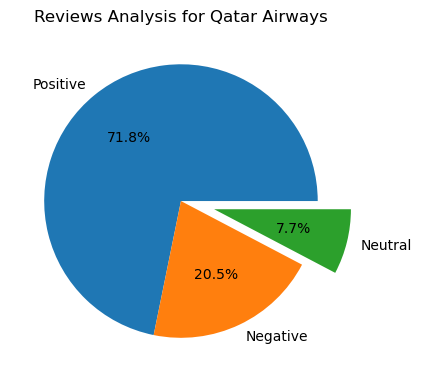

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(15,7))

plt.subplot(1,3,2)
plt.title(f"Reviews Analysis for {airline_name}")
plt.pie(vader_counts.values, labels = vader_counts.index, explode = (0, 0, 0.25), autopct='%1.1f%%', shadow=False)
plt.show()


#### ii. Wordcloud

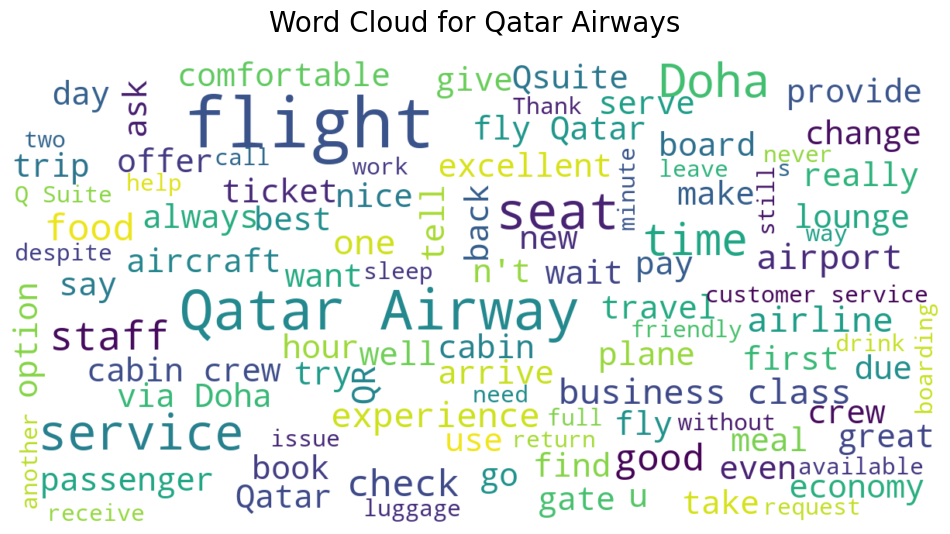

In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS


stopwords = set(STOPWORDS)

def show_wordcloud(data, airline_name):
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1
    ).generate(" ".join(data.astype(str)))  

    fig = plt.figure(figsize=(12, 12)) 
    ax = fig.add_subplot(111)  
    ax.imshow(wordcloud, interpolation='bilinear')  
    ax.axis('off')  
    ax.set_title(f"Word Cloud for {airline_name}", fontsize=20, pad=20)  # Set title with airline name

    plt.show()  

show_wordcloud(df.Lemma, airline_name)
